# 1- Importing and matching Data

- Get Parent directory from any location
- Import GEM xml file with original information
- Import firtered Compound Graph

In [3]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from etc.parse_ids import XMLParser

# Get the notebook's directory and go up to project root
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
data_folder = project_root / "data" / "resources"
Pilot = data_folder / "PilotStudy_All"

# Get graph prevouly fitered
graph_gml = data_folder / "generated" / "modified_graph.gml"
# Get the original graph for matching ids
human1_xml = data_folder / "Human-GEM.xml"

### Consortium sumarized data from different samples
- First we define a method to match the chebis with the HUMAN1
- Then upload data and apply changes

In [4]:
# Auxiliar function to extract the chebi number from a string like "CHEBI:12345"
def extract_single_chebi(value):
    """Extract CHEBI number from a single CHEBI string"""
    if pd.isna(value):
        return None
    match = re.search(r"CHEBI:(\d+)", str(value))
    if match:
        return int(match.group(1))
    return None

- Load the Pilot Study compilation
- Filter level 1 ids
- Add a chebi number only column

In [5]:
# Load the data file as a pandas DataFrame
data_file = pd.read_excel(Pilot / "Daniel_Suplementary_info.xlsx", sheet_name="Sheet1")

# Filter to only include rows where ID_level is 1
data_file = data_file[data_file.ID_level==1]

# Add new column with extracted CHEBI numbers
data_file['CHEBI_number'] = data_file.CHEBI_ID_Step2.apply(extract_single_chebi)

### From HUMAN1 GEM xml file 
- Create a dataframe
- Create colum to match chebis ids and link them with human1 ids

In [6]:
parser = XMLParser(human1_xml)
df = parser.extract_data()
df_human1 = parser.to_identifier_df()
df_human1['Consortium'] = None

### Matching and filling column

In [7]:
# Convert df_human1 CHEBI to integers for matching
df_human1['chebi_int'] = pd.to_numeric(df_human1['chebi'], errors='coerce').astype('Int64')
# Get set of CHEBIs from data_file
data_file_chebis = set(data_file['CHEBI_number'].dropna().values)

# Fill Consortium column with boolean: True if CHEBI matches, False otherwise
df_human1['Consortium'] = df_human1['chebi_int'].isin(data_file_chebis)

print(f"Consortium column filled with boolean values")
print(f"True matches: {df_human1['Consortium'].sum()}")
print(f"False (no match): {(~df_human1['Consortium']).sum()}")

Consortium column filled with boolean values
True matches: 356
False (no match): 8100


In [8]:
# Find CHEBIs in data_file that are NOT in df_human1
df_human1_chebis = set(df_human1['chebi_int'].dropna().values)
data_file_chebis_set = set(data_file['CHEBI_number'].dropna().values)

# CHEBIs not found in df_human1
unmatched_chebis = data_file_chebis_set - df_human1_chebis

print(f"Total CHEBIs in data_file: {len(data_file_chebis_set)}")
print(f"CHEBIs found in df_human1: {len(data_file_chebis_set - unmatched_chebis)}")
print(f"CHEBIs NOT found in df_human1: {len(unmatched_chebis)}")
print(f"\nUnmatched CHEBIs: {sorted(unmatched_chebis)}")

Total CHEBIs in data_file: 228
CHEBIs found in df_human1: 105
CHEBIs NOT found in df_human1: 123

Unmatched CHEBIs: [np.int64(4139), np.int64(4828), np.int64(9008), np.int64(11901), np.int64(14314), np.int64(15620), np.int64(15761), np.int64(16020), np.int64(16113), np.int64(16119), np.int64(16231), np.int64(16312), np.int64(16347), np.int64(16373), np.int64(16831), np.int64(17012), np.int64(17016), np.int64(17072), np.int64(17234), np.int64(17597), np.int64(17687), np.int64(17780), np.int64(18123), np.int64(19030), np.int64(19062), np.int64(19065), np.int64(19660), np.int64(21264), np.int64(21553), np.int64(21563), np.int64(21756), np.int64(21949), np.int64(25858), np.int64(27410), np.int64(27596), np.int64(27732), np.int64(27747), np.int64(27838), np.int64(28123), np.int64(28177), np.int64(28238), np.int64(28393), np.int64(28664), np.int64(28717), np.int64(28775), np.int64(28821), np.int64(28871), np.int64(28946), np.int64(30753), np.int64(30776), np.int64(30845), np.int64(35280), np

note: 123 metbolites from the data couldn't be match on HUMAN1, note some are lipis and most of them considered sidecompounds that will not be taken into account in the model. Also we only included level 1 annotated metabolites

### Mask separated annotations on HUMAN1 dataframe

In [9]:
capitainer = data_file[data_file.Capitainer == "Yes"]
mitra = data_file[data_file.Mitra == "Yes"]
blood = data_file[data_file.Blood == "Yes"]
plasma = data_file[data_file.Plasma == "Yes"]

devices = {
    "Capitainer": capitainer,
    "Mitra": mitra,
    "Blood": blood,
    "Plasma": plasma
}
for device_name, device_df in devices.items():
    chebis = set(device_df['CHEBI_number'].dropna().values)
    df_human1[device_name] = df_human1['chebi_int'].isin(device_df['CHEBI_number'].dropna().values)

    print(f"{device_name} column filled with boolean values")
    print(f"True matches: {df_human1[device_name].sum()}")
    print(f"False (no match): {(~df_human1[device_name]).sum()}")

Capitainer column filled with boolean values
True matches: 332
False (no match): 8124
Mitra column filled with boolean values
True matches: 338
False (no match): 8118
Blood column filled with boolean values
True matches: 321
False (no match): 8135
Plasma column filled with boolean values
True matches: 330
False (no match): 8126


# 1.1- Matching data on the HUMAN1 graph
After removing compartments and removing isolated nodes
we get the compund graph from the HUMAN1 GEM

In [ ]:
import networkx as nx
from matplotlib import pyplot as plt
from upsetplot import UpSet, from_memberships

graph = nx.read_gml(graph_gml)
n = graph.number_of_nodes()
graph_nodes = list(graph.nodes())
node_to_index = {node: idx for idx, node in enumerate(graph_nodes)}

print(f"Graph loaded with {n} nodes.")
print(f"Graph has {graph.number_of_edges()} edges.")
print(f"Graph is connected: {nx.is_connected(graph)}")

Graph loaded with 3240 nodes.
Graph has 7254 edges.
Graph is connected: True


### Then matching the devices metabolites to the graph nodes 

In [11]:
device_indices = {}

for device_name in ['Mitra', 'Capitainer', 'Blood', 'Plasma']:
    device_filtered = df_human1[df_human1[device_name] == True]
    device_ids = set(device_filtered.index.tolist())

    selected_indices = [node_to_index[node_id] for node_id in device_ids if node_id in node_to_index]
    device_indices[device_name] = selected_indices
    print(f"{device_name} indices mapped to graph nodes: {len(selected_indices)} found.")

Mitra indices mapped to graph nodes: 77 found.
Capitainer indices mapped to graph nodes: 75 found.
Blood indices mapped to graph nodes: 70 found.
Plasma indices mapped to graph nodes: 73 found.


/home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/venv/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/venv/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead

<Figure size 1000x600 with 0 Axes>

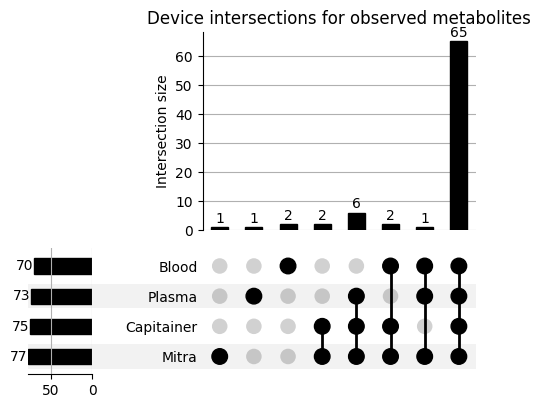

In [ ]:
# Build membership list for each observed graph node
all_nodes = sorted(set().union(*device_indices.values()))
memberships = [
    tuple(sorted([device for device, indices in device_indices.items() if node_idx in indices]))
    for node_idx in all_nodes
]

upset_data = from_memberships(memberships)

plt.figure(figsize=(10, 6))
upset = UpSet(upset_data, subset_size='count', show_counts=True, sort_by='degree')
upset.plot()
plt.title('Device intersections for observed metabolites')
plt.tight_layout()
plt.savefig(data_folder / "figs" / "device_intersections_upset.png")
plt.show()

### Degree distribution

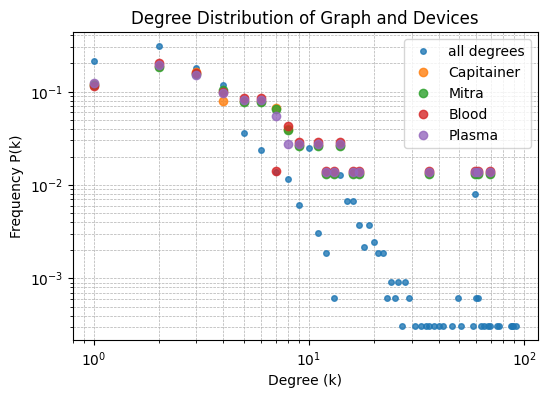

In [10]:
degrees = [d for _, d in graph.degree()]
unique, counts = np.unique(degrees, return_counts=True)

degree_devices = {
    device_name: np.array(degrees)[device_indices[device_name]] for device_name in devices.keys()
    }
freq = counts / counts.sum()

plt.figure(figsize=(6,4))
plt.loglog(unique, freq, 'o', markersize=4, label='all degrees', alpha=0.8)
for device_name, device_degrees in degree_devices.items():
    unique_dev, counts_dev = np.unique(device_degrees, return_counts=True)
    freq_dev = counts_dev / counts_dev.sum()
    plt.loglog(unique_dev, freq_dev, 'o', markersize=6, label=device_name, alpha=0.8)
plt.xlabel('Degree (k)')
plt.ylabel('Frequency P(k)')
plt.title('Degree Distribution of Graph and Devices')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)

plt.savefig(data_folder / 'figs' / "degree_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [50]:
observed_nodes = [
    n for n in df_human1.index
    if df_human1.loc[n, "Consortium"] and n in graph
    ]
observed_indices = [node_to_index[node_id] for node_id in observed_nodes]

connector_indices = set(observed_indices)

for i, source_node in enumerate(observed_nodes):
    for target_node in observed_nodes[i + 1 :]:
        try:
            path = nx.shortest_path(graph, source=source_node, target=target_node)
            connector_indices.update(node_to_index[node_id] for node_id in path)
        except nx.NetworkXNoPath:
            pass

print(f"Total observed nodes (including connectors): {len(connector_indices)}")
connector_nodes = [graph_nodes[idx] for idx in connector_indices]

G_observed = graph.subgraph(connector_nodes).copy()
print(G_observed)
print(f"Nodes: {G_observed.number_of_nodes()}")
print(f"Edges: {G_observed.number_of_edges()}")

Total observed nodes (including connectors): 362
Graph with 362 nodes and 728 edges
Nodes: 362
Edges: 728


In [14]:
from collections import defaultdict

def graph_voronoi_partition(G, observed_nodes):
    """
    Assign each node in G to the closest observed node.
    This creates graph-based Voronoi regions using shortest-path distance.
    """

    distances, paths = nx.multi_source_dijkstra(
        G,
        sources=observed_nodes,
        weight=None
    )

    node_to_seed = {}

    for node, path in paths.items():
        seed = path[0]  # first node in path is the closest observed source
        node_to_seed[node] = seed

    return node_to_seed, distances

In [16]:
node_to_seed, distance_to_observed = graph_voronoi_partition(
    graph,
    observed_nodes
)

In [17]:
pos = nx.spring_layout(
    graph,
    seed=42,
    k=0.08,
    iterations=100
)

In [20]:
seed_to_id = {
    seed: i
    for i, seed in enumerate(observed_nodes)
}

In [21]:
node_colors = [
    seed_to_id[node_to_seed[n]]
    for n in graph.nodes()
]

In [22]:
node_sizes = [
    40 if n in observed_nodes else 5
    for n in graph.nodes()
]

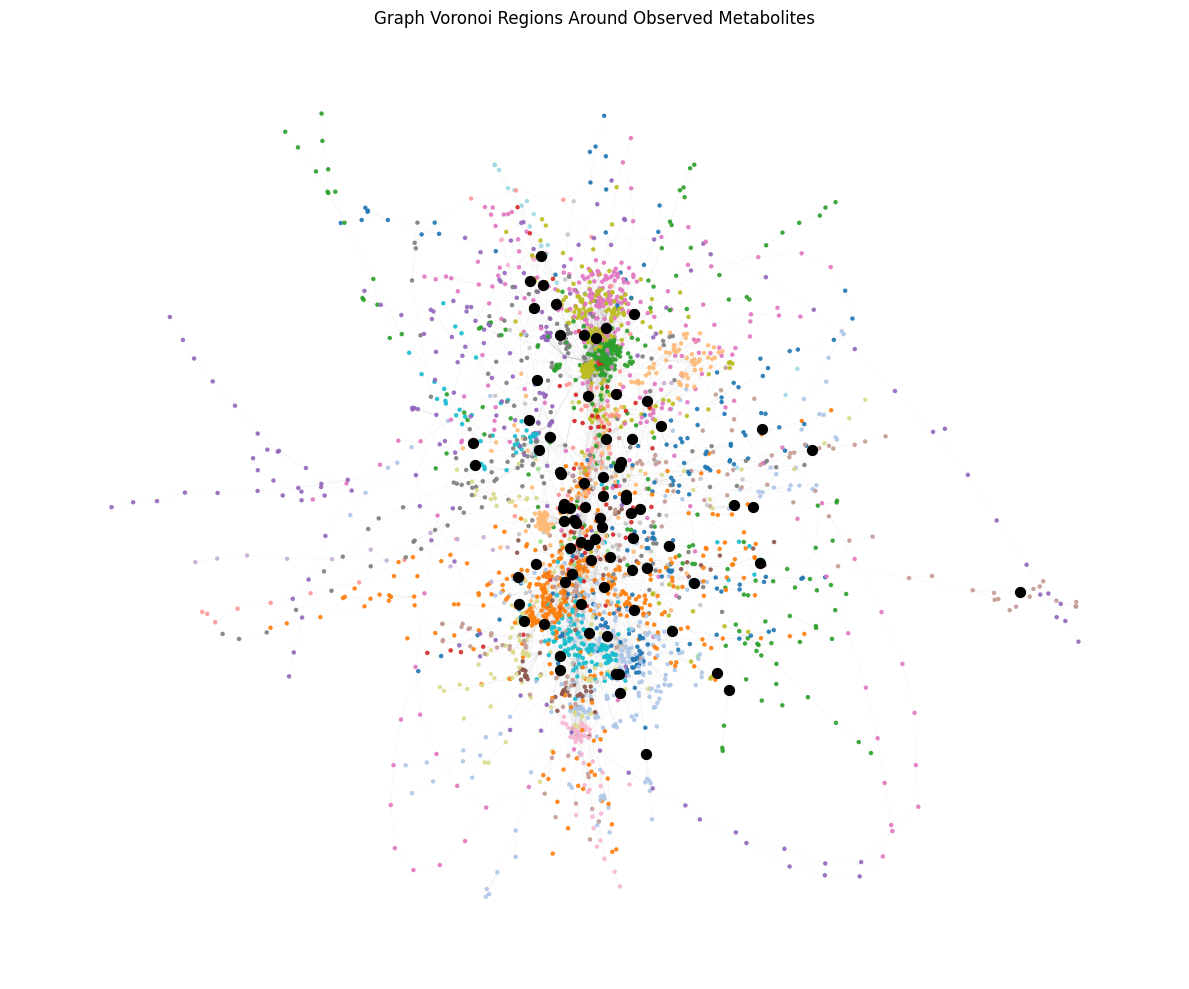

In [23]:
plt.figure(figsize=(12, 10))

nx.draw_networkx_edges(
    graph,
    pos,
    alpha=0.05,
    width=0.3
)

nx.draw_networkx_nodes(
    graph,
    pos,
    node_color=node_colors,
    cmap="tab20",
    node_size=node_sizes,
    alpha=0.85
)

# Highlight observed nodes
nx.draw_networkx_nodes(
    graph,
    pos,
    nodelist=observed_nodes,
    node_color="black",
    node_size=50,
    alpha=1.0
)

plt.title("Graph Voronoi Regions Around Observed Metabolites")
plt.axis("off")
plt.tight_layout()
plt.show()

In [25]:
def assign_seed_device(seed, device_indices):
    detected_by = []

    for device, nodes in device_indices.items():
        if seed in set(nodes):
            detected_by.append(device)

    if len(detected_by) == 0:
        return "Connector"
    elif len(detected_by) == 1:
        return detected_by[0]
    else:
        return "Shared"


node_zone_type = {}

for node in graph.nodes():
    seed = node_to_seed[node]
    node_zone_type[node] = assign_seed_device(seed, device_indices)

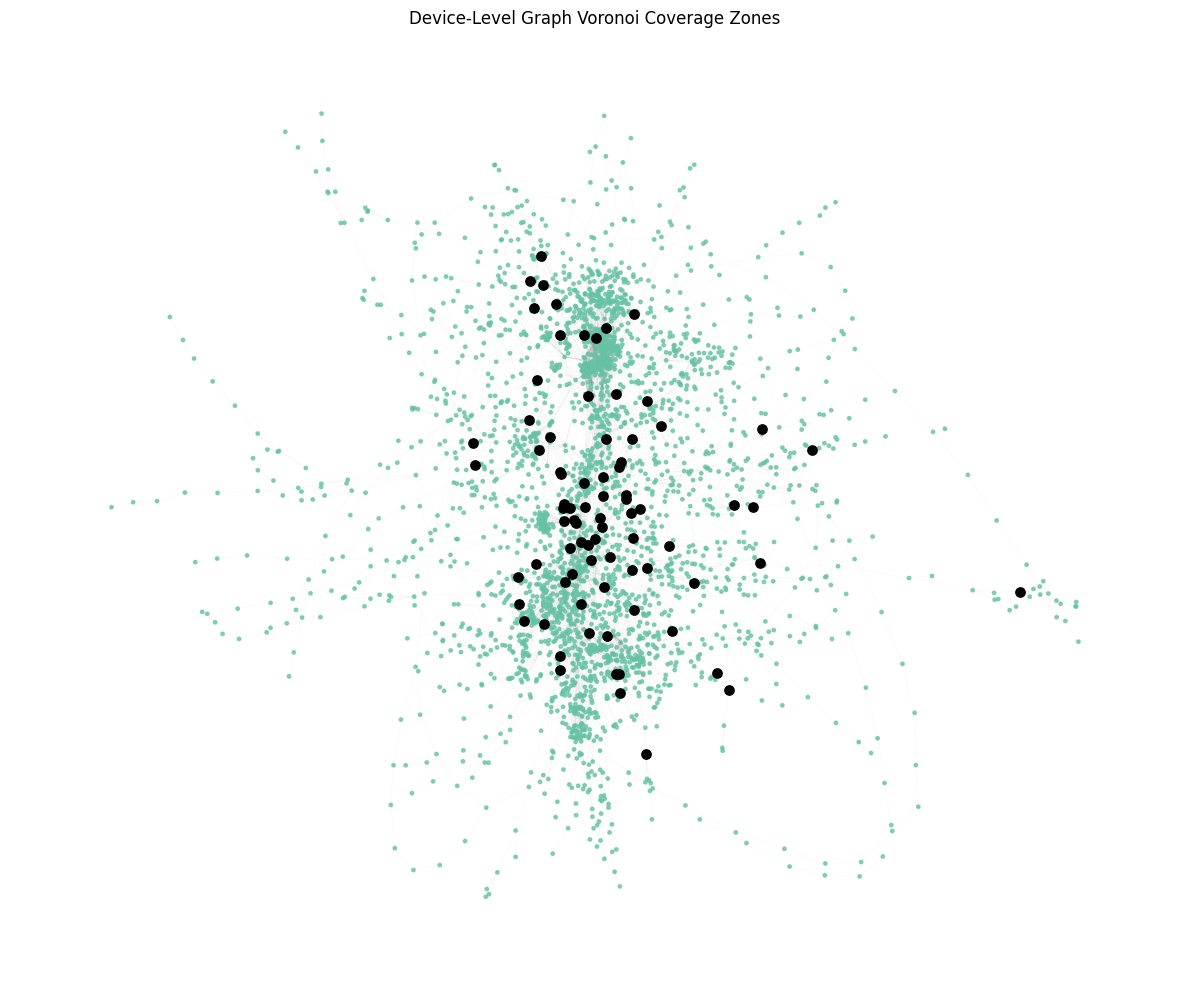

['Connector']


In [26]:
zone_categories = sorted(set(node_zone_type.values()))

zone_to_id = {
    zone: i
    for i, zone in enumerate(zone_categories)
}

node_colors = [
    zone_to_id[node_zone_type[n]]
    for n in graph.nodes()
]

plt.figure(figsize=(12, 10))

nx.draw_networkx_edges(
    graph,
    pos,
    alpha=0.04,
    width=0.3
)

nx.draw_networkx_nodes(
    graph,
    pos,
    node_color=node_colors,
    cmap="Set2",
    node_size=6,
    alpha=0.75
)

nx.draw_networkx_nodes(
    graph,
    pos,
    nodelist=observed_nodes,
    node_color="black",
    node_size=45,
    alpha=1.0
)

plt.title("Device-Level Graph Voronoi Coverage Zones")
plt.axis("off")
plt.tight_layout()
plt.show()

print(zone_categories)

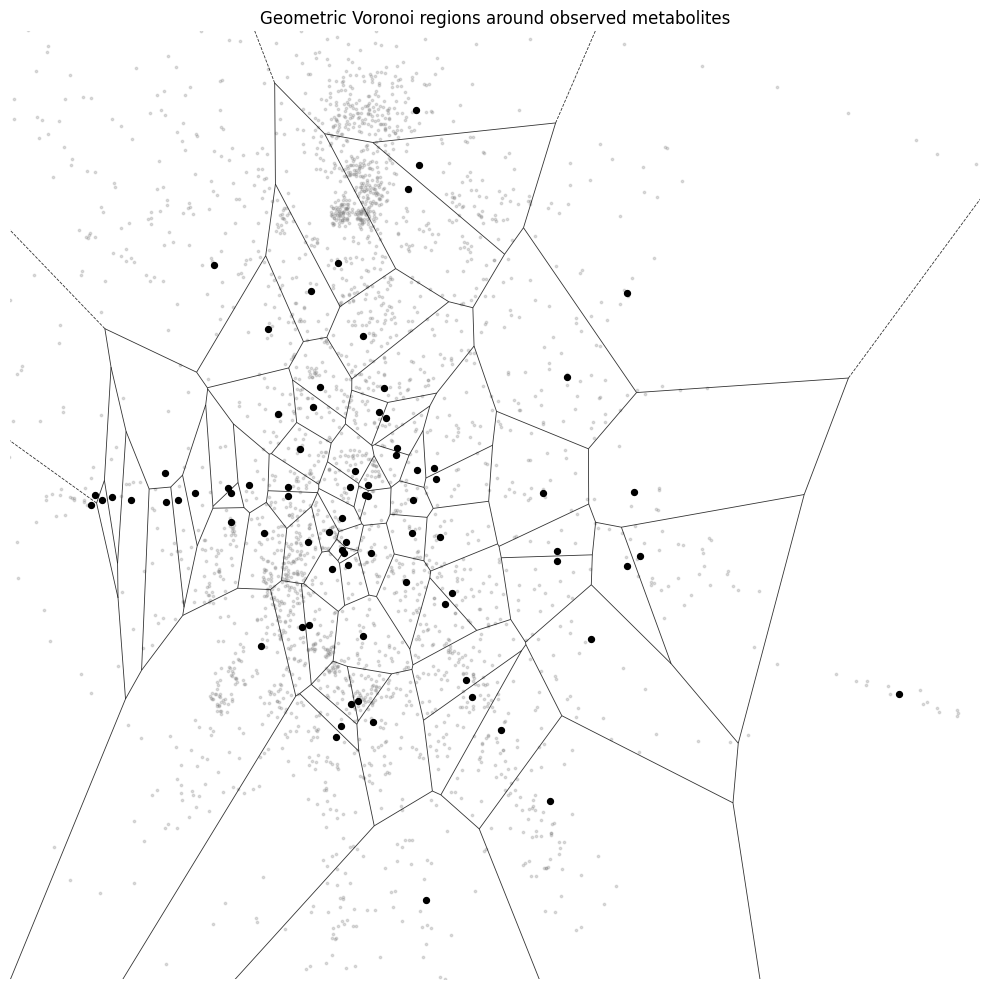

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial import Voronoi, voronoi_plot_2d
import numpy as np

# 1. Get 2D coordinates for all graph nodes
pos = nx.spring_layout(graph, seed=42, iterations=200)

# 2. Observed nodes = union across devices
observed_nodes = sorted(set().union(*[set(v) for v in device_indices.values()]))
observed_nodes = [n for n in observed_nodes if n in graph]

points = np.array([pos[n] for n in observed_nodes])

# 3. Compute Voronoi from observed metabolites
import matplotlib.pyplot as plt

# 1. Get 2D coordinates for all graph nodes
pos = nx.spring_layout(graph, seed=42, iterations=200)

# 2. Observed nodes = union across devices
observed_indices = sorted(set().union(*[set(v) for v in device_indices.values()]))
observed_nodes = [graph_nodes[idx] for idx in observed_indices if idx < len(graph_nodes)]
points = np.array([pos[n] for n in observed_nodes])

if points.ndim != 2 or points.shape[0] < 2:
    raise ValueError(f"Need at least 2 observed points for Voronoi, got {points.shape}")

# 3. Compute Voronoi from observed metabolites
vor = Voronoi(points)

# 4. Plot Voronoi regions
fig, ax = plt.subplots(figsize=(10, 10))

voronoi_plot_2d(
    vor,
    ax=ax,
    show_vertices=False,
    show_points=False,
    line_width=0.6,
    line_alpha=0.8
)

# 5. Plot all Human1 nodes in background
all_xy = np.array([pos[n] for n in graph.nodes()])
ax.scatter(
    all_xy[:, 0],
    all_xy[:, 1],
    s=3,
    alpha=0.25,
    color="gray"
)

# 6. Plot observed metabolites
ax.scatter(
    points[:, 0],
    points[:, 1],
    s=18,
    color="black",
    zorder=5
)

ax.set_title("Geometric Voronoi regions around observed metabolites")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [14]:
# Export the observed subgraph to GML format
for node in G_observed.nodes():
    if node in df_human1.index:
        G_observed.nodes[node]["Mitra"] = bool(df_human1.at[node, "Mitra"])
        G_observed.nodes[node]["Capitainer"] = bool(df_human1.at[node, "Capitainer"])
        G_observed.nodes[node]["Blood"] = bool(df_human1.at[node, "Blood"])
        G_observed.nodes[node]["Plasma"] = bool(df_human1.at[node, "Plasma"])
    else:
        G_observed.nodes[node]["Mitra"] = False
        G_observed.nodes[node]["Capitainer"] = False
        G_observed.nodes[node]["Blood"] = False
        G_observed.nodes[node]["Plasma"] = False

output_gml_path = data_folder / "generated" / "observed_subgraph.gml"
nx.write_gml(G_observed, output_gml_path)
print(f"Observed subgraph exported to: {output_gml_path}")

Observed subgraph exported to: /home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/data/resources/generated/observed_subgraph.gml


# 2- Model application
Importing the $H$ function and calculate energy for different k or devices

In [29]:
from etc.hamiltonian import Hamiltonian
from etc.coverage import Coverage
from itertools import combinations

#### Define H object and parameters $\mu$ and $\gamma$
- method to binarize index lists

In [30]:
H = Hamiltonian(graph)
coverage = Coverage(H)

mu = H.mu_density_aware(graph)
gamma = H.gamma_balancer(mu=mu)

print(f"Gamma value set to: {gamma:.4f}")
print(f"Mu value set to: {mu:.4f}")

def S0(idx,nodes):
    mask = np.zeros(len(nodes), dtype=bool)
    mask[idx] = True
    return mask

Gamma value set to: 2.5562
Mu value set to: 0.9986


In [38]:
inD2 = H.Dinv2_triu

def condensed_to_symmetric(ind2, n):
    """
    Convert condensed upper-triangular vector
    to full symmetric matrix.
    """
    K = np.zeros((n, n), dtype=float)
    iu = np.triu_indices(n, k=1)
    K[iu] = ind2
    K[(iu[1], iu[0])] = ind2
    return K

# Handle both 1D (condensed) and 2D (full matrix) formats
if inD2.ndim == 2:
    print(f"inD2 is 2D matrix {inD2.shape}. Extracting upper triangle...")
    iu = np.triu_indices(n, k=1)
    ind2_condensed = inD2[iu]
    print(f"Extracted condensed form shape: {ind2_condensed.shape}")
    K = condensed_to_symmetric(ind2_condensed, n)
else:
    print(f"inD2 is 1D condensed form with shape {inD2.shape}")
    K = condensed_to_symmetric(inD2, n)

print(f"K shape: {K.shape}")
print(f"K is symmetric: {np.allclose(K, K.T)}")

inD2 is 2D matrix (3240, 3240). Extracting upper triangle...
Extracted condensed form shape: (5247180,)
K shape: (3240, 3240)
K is symmetric: True


In [39]:
observed = sorted(
    set().union(*[set(v) for v in device_indices.values()])
)

observed = [n for n in observed if n in graph]

remaining = [
    n for n in graph.nodes()
    if n not in observed
]

ordered_nodes = observed + remaining

In [41]:
node_order = list(graph.nodes())

node_to_idx = {
    node: i
    for i, node in enumerate(node_order)
}

In [42]:
perm = np.array([
    node_to_idx[n]
    for n in ordered_nodes
])

In [43]:
K_ordered = K[np.ix_(perm, perm)]

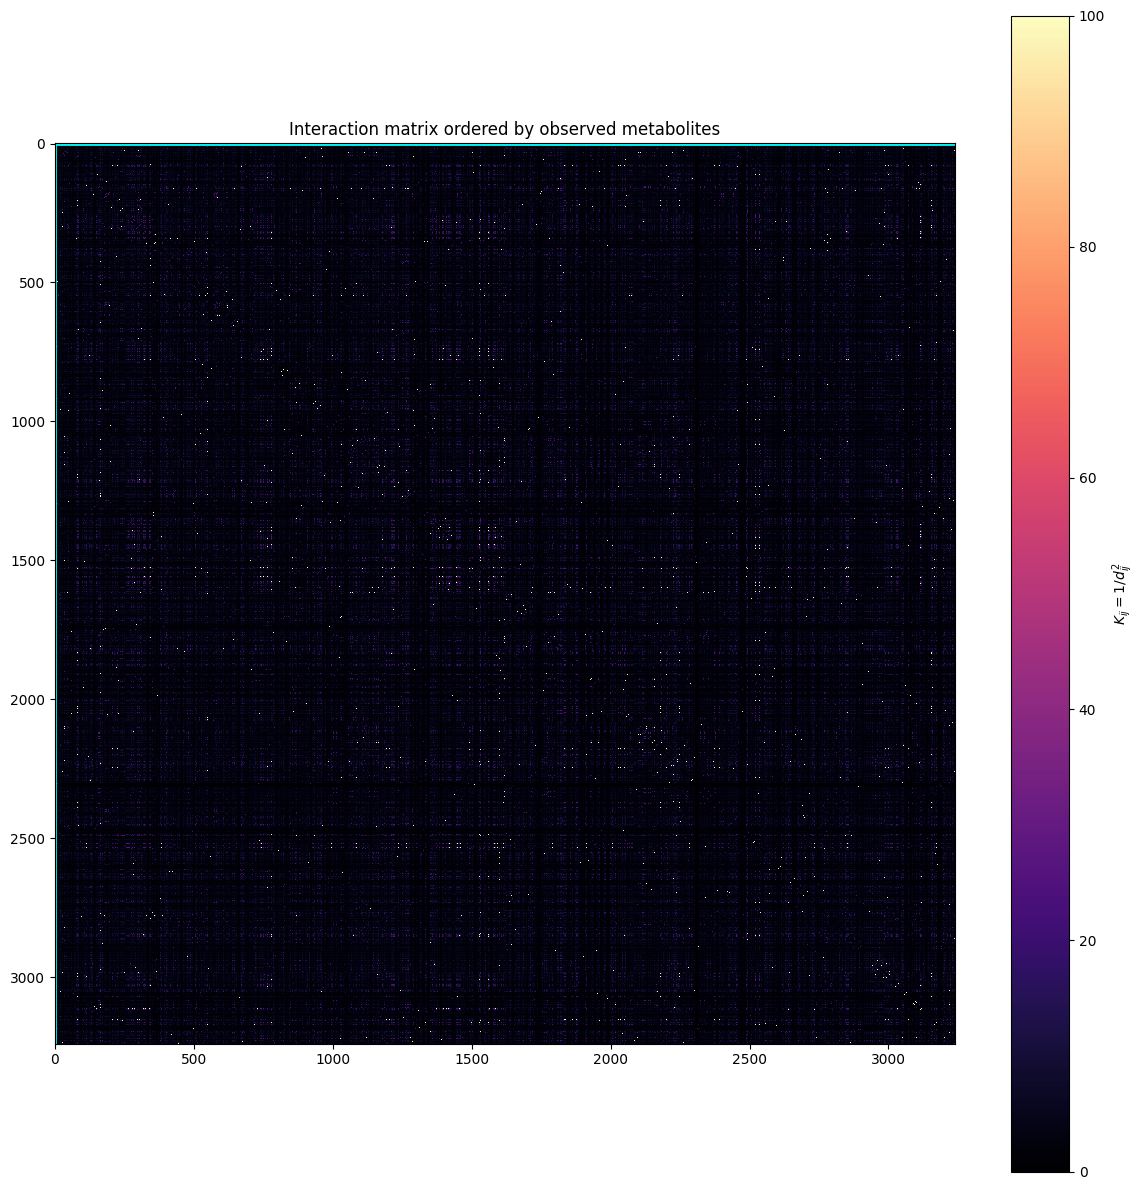

In [46]:
k = len(observed)

plt.figure(figsize=(12, 12))

plt.imshow(
    K_ordered*100,
    cmap="magma",
    interpolation="nearest"
)

# Observed / unobserved boundary
plt.axvline(k, color="cyan", lw=2)
plt.axhline(k, color="cyan", lw=2)

plt.colorbar(
    label=r"$K_{ij}=1/d_{ij}^{2}$"
)

plt.title(
    "Interaction matrix ordered by observed metabolites"
)

plt.tight_layout()
plt.show()

In [51]:
def pair_distance_counts(G, nodes, max_distance=6):
    """
    Count observed-observed pairs at distances 1, 2, ..., max_distance.
    Pairs farther than max_distance are grouped as >max_distance.
    """
    nodes = [n for n in nodes if n in G]
    counts = {d: 0 for d in range(1, max_distance + 1)}
    counts[f">{max_distance}"] = 0

    total_pairs = 0

    for u, v in combinations(nodes, 2):
        try:
            d = nx.shortest_path_length(G, u, v)
            total_pairs += 1

            if d <= max_distance:
                counts[d] += 1
            else:
                counts[f">{max_distance}"] += 1

        except nx.NetworkXNoPath:
            pass

    return counts, total_pairs


def random_pair_distance_baseline(
    G,
    k,
    n_random=1000,
    max_distance=6,
    seed=42
):
    rng = np.random.default_rng(seed)
    all_nodes = np.array(list(G.nodes()))

    rows = []

    for r in range(n_random):
        sample = rng.choice(all_nodes, size=k, replace=False)
        counts, total_pairs = pair_distance_counts(
            G,
            sample,
            max_distance=max_distance
        )

        row = {"random_id": r, "total_pairs": total_pairs}
        row.update(counts)
        rows.append(row)

    return pd.DataFrame(rows)


# --------------------------------------------------
# Observed nodes: union across devices
# --------------------------------------------------

observed_nodes = observed_nodes

observed_nodes = [n for n in observed_nodes if n in graph]

k = len(observed_nodes)

print(f"Observed nodes: {k}")


# --------------------------------------------------
# Observed counts
# --------------------------------------------------

max_distance = 6

observed_counts, total_pairs = pair_distance_counts(
    graph,
    observed_nodes,
    max_distance=max_distance
)

observed_df = pd.DataFrame({
    "distance": list(observed_counts.keys()),
    "observed_count": list(observed_counts.values())
})

observed_df["observed_fraction"] = (
    observed_df["observed_count"] / total_pairs
)

print(observed_df)


# --------------------------------------------------
# Random baseline
# --------------------------------------------------

baseline = random_pair_distance_baseline(
    graph,
    k=k,
    n_random=1000,
    max_distance=max_distance,
    seed=42
)

distance_cols = list(observed_counts.keys())

baseline_summary = pd.DataFrame({
    "distance": distance_cols,
    "random_mean": baseline[distance_cols].mean().values,
    "random_low": baseline[distance_cols].quantile(0.025).values,
    "random_high": baseline[distance_cols].quantile(0.975).values,
})

baseline_summary["random_fraction_mean"] = (
    baseline_summary["random_mean"] / total_pairs
)

baseline_summary["random_fraction_low"] = (
    baseline_summary["random_low"] / total_pairs
)

baseline_summary["random_fraction_high"] = (
    baseline_summary["random_high"] / total_pairs
)

plot_df = observed_df.merge(
    baseline_summary,
    on="distance"
)

print(plot_df)

Observed nodes: 80
  distance  observed_count  observed_fraction
0        1              47           0.014873
1        2             111           0.035127
2        3             302           0.095570
3        4             577           0.182595
4        5             620           0.196203
5        6             543           0.171835
6       >6             960           0.303797
  distance  observed_count  observed_fraction  random_mean  random_low  \
0        1              47           0.014873        4.183       0.000   
1        2             111           0.035127       37.270      18.000   
2        3             302           0.095570      124.093      71.975   
3        4             577           0.182595      294.204     192.975   
4        5             620           0.196203      487.358     360.850   
5        6             543           0.171835      576.169     458.925   
6       >6             960           0.303797     1636.723    1267.900   

   random_high  rand

In [60]:
D = H.distance_matrix
D_obs = D[np.ix_(observed_indices, observed_indices)]
iu = np.triu_indices_from(D_obs, k=1)
pair_distances = D_obs[iu]
iu_full = np.triu_indices_from(D, k=1)
network_mean_distance = np.mean(D[iu_full])
print(network_mean_distance)

7.39200789757546


In [113]:
(D_obs==7).sum()/2

np.float64(481.0)

In [99]:
D.sum() / (n*(n-1)/2)

np.float64(14.78401579515092)

In [114]:
7*3

21

In [93]:
3200-80

3120

In [61]:
close_pairs = pair_distances[
    pair_distances < network_mean_distance
]

fraction_close = (
    len(close_pairs)
    / len(pair_distances)
)

print(
    f"Fraction below network mean distance: "
    f"{fraction_close:.3f}"
)

Fraction below network mean distance: 0.848


#### Define devices' dictionary with values of $\mathcal{H}$

In [108]:
device_h_values = {}
for device_name in devices.keys():
    h,t1,t2 = H.compute(device_indices[device_name], gamma=0.23, mu=mu)
    device_h_values[device_name] = [h, t1, t2]
    
print("H values computed for each device:")
for device_name, values in device_h_values.items():
    print(f"{device_name}: H={values[0]:.4f}, t1={values[1]:.4f}, t2={values[2]:.4f}, k={len(device_indices[device_name])}")

H values computed for each device:
Capitainer: H=-0.7541, t1=-41.9419, t2=41.1878, k=75
Mitra: H=-0.8190, t1=-44.9378, t2=44.1188, k=77
Blood: H=-1.2832, t1=-35.9502, t2=34.6670, k=70
Plasma: H=1.0552, t1=-35.9502, t2=37.0054, k=73


### Find $\gamma$ to balance $\mathcal{H}$

    device  gamma_estimate
     Mitra        0.234269
Capitainer        0.234211
     Blood        0.238514
    Plasma        0.223442
    device  k    gamma   best_abs_H  best_signed_H
     Blood 70 0.715541 3.375700e-07  -3.375700e-07
Capitainer 75 0.223189 1.566838e-07  -1.566838e-07
     Mitra 77 0.023427 5.607401e-08   5.607401e-08
    Plasma 73 0.022344 1.276668e-07  -1.276668e-07


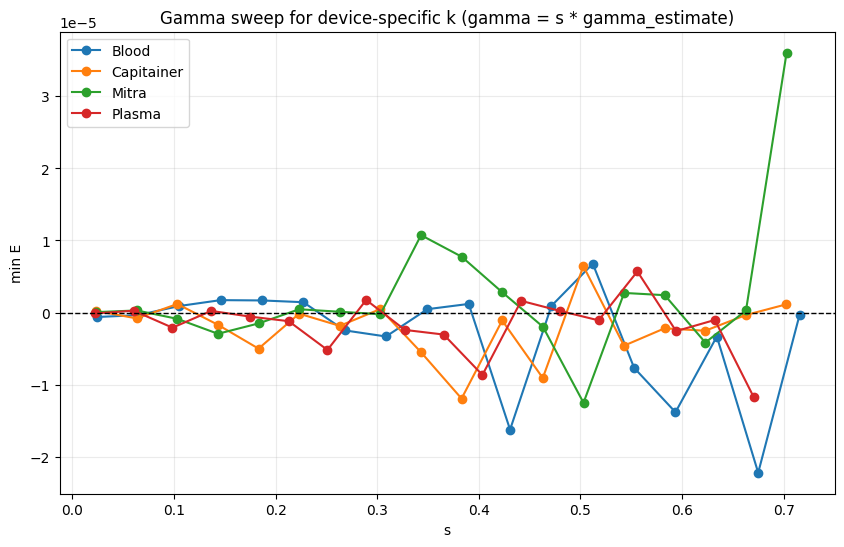

In [105]:
device_h_components = {}
for name in device_indices.keys():
    h_val, t1, t2 = H.compute(device_indices[name], mu=mu, gamma=gamma)
    device_h_components[name] = (h_val, t1, t2)

# Estimate a per-device gamma from the current H balance without creating the later energy arrays yet.
device_gamma_estimates = {}
for name, (h_val, t1, t2) in device_h_components.items():
    if t2 is None or abs(t2) < 1e-12:
        est = float(gamma)
    else:
        est = float((-t1 * float(gamma)) / float(t2))
    device_gamma_estimates[name] = max(1e-3, est)


def gamma_annealing_sweep(device_name, gamma_grid, steps=150000, seed=42, Tmax=1.0, Tmin=1e-50, cooloing=0.995):
    device_mask = S0(device_indices[device_name], node_to_index.values())
    rows = []

    for gamma_candidate in gamma_grid:
        best_mask, best_energy, history = coverage.min_energy_anneling(
            S0=device_mask,
            mu=mu,
            gamma=float(gamma_candidate),
            Tmax=Tmax,
            Tmin=Tmin,
            cooloing=cooloing,
            seed=seed,
            steps=steps,
        )
        best_indices = np.where(best_mask == 1)[0]
        best_h, _, _ = H.compute(best_indices, mu=mu, gamma=float(gamma_candidate))
        rows.append(
            {
                "device": device_name,
                "k": int(device_mask.sum()),
                "gamma": float(gamma_candidate),
                "best_abs_H": float(best_energy),
                "best_signed_H": float(best_h),
                "history_min": float(np.min(history)) if len(history) > 0 else float('nan'),
                "history_last": float(history[-1]) if len(history) > 0 else float('nan'),
            }
        )

    return pd.DataFrame(rows)

scan_frames = []
for name in device_indices.keys():
    gamma_estimate = device_gamma_estimates[name]
    gamma_grid = np.linspace(max(0.01, 0.1 * gamma_estimate), max(0.01, 3.0 * gamma_estimate), 18)
    scan_frames.append(gamma_annealing_sweep(name, gamma_grid, steps=1500000, seed=42,Tmin=1e-1000))

annealing_scan = pd.concat(scan_frames, ignore_index=True)

best_gamma_by_device = (
    annealing_scan.sort_values(["device", "best_abs_H"])
    .groupby("device", as_index=False)
    .first()[["device", "k", "gamma", "best_abs_H", "best_signed_H"]]
)

print(pd.DataFrame({"device": list(device_gamma_estimates.keys()),
                    "gamma_estimate": list(device_gamma_estimates.values())}).to_string(index=False))
print(best_gamma_by_device.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
for device_name, device_df in annealing_scan.groupby("device"):
    ax.plot(device_df["gamma"], device_df["best_signed_H"], marker="o", linewidth=1.5, label=device_name)

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
ax.set_xlabel('s')
ax.set_ylabel('min E')
ax.set_title('Gamma sweep for device-specific k (gamma = s * gamma_estimate)')
ax.legend()
ax.grid(True, alpha=0.25)
out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'gamma_sweep_plot.png', dpi=400, bbox_inches='tight')
plt.show()

#### Binary vectors $s_{i}$ for devices

In [20]:
gamma = 0.23
S0_Capitainer = S0(device_indices['Capitainer'], graph_nodes)
S0_Mitra = S0(device_indices['Mitra'], graph_nodes)
S0_Blood = S0(device_indices['Blood'], graph_nodes)
S0_Plasma = S0(device_indices['Plasma'], graph_nodes)

# 2.1 - Energy evaluation and random sampling
Random sampling for different k

In [21]:
def sampling_energy(n,k, gamma, mu, n_samples=10000,seed=42):

    rng = np.random.default_rng(seed)
    energies = []
    samples = []
    for _ in range(n_samples):

        sample = rng.choice(n, size=k, replace=False)
        E = H.compute(sample, gamma=gamma, mu=mu)[0]
        energies.append(abs(E))
        samples.append(sample)
        

    energies = np.array(energies)
    samples = np.array(samples)

    return energies, samples[energies.argmin()], samples[energies.argmax()]

The random sampling takes around 2h

In [109]:
sampling_results = {}
for device_name in devices.keys():
     k = len(device_indices[device_name])
     energies, best_sample, worst_sample = sampling_energy(n, k, gamma=0.23, mu=mu, n_samples=10000000, seed=42)
     sampling_results[device_name] = (energies, best_sample, worst_sample)
     print(
         f"{device_name}: Best energy={energies.min():.4f}, Worst energy={energies.max():.4f}")

Capitainer: Best energy=0.0851, Worst energy=29.5053
Mitra: Best energy=0.2528, Worst energy=32.0429
Blood: Best energy=0.1615, Worst energy=26.7273
Plasma: Best energy=0.5115, Worst energy=28.0781


Store it in a txt file to fast experiments

In [ ]:
# # Store the sampling results in a txt file
results_file = data_folder /"generated" / "sampling_results.txt"
# with open(results_file, 'w') as f:
#     for device_name, (energies, best_sample, worst_sample) in sampling_results.items():
#         f.write(f"{device_name}:\n")
#         f.write(f"Best energy: {energies.min():.4f}\n")
#         f.write(f"Worst energy: {energies.max():.4f}\n")
#         f.write(f"Best sample indices: {best_sample}\n")
#         f.write(f"Worst sample indices: {worst_sample}\n\n")

In [ ]:
with open(results_file, 'r') as f:
    contents = f.read()

best_sample_indices_by_device = {}
worst_sample_indices_by_device = {}
best_sample_indices_raw_by_device = {}
worst_sample_indices_raw_by_device = {}

for section in contents.strip().split("\n\n"):
    section = section.strip()
    if not section:
        continue

    header_match = re.match(r"^(.*?):", section)
    if header_match is None:
        continue

    device_name = header_match.group(1).strip()
    best_match = re.search(r"Best sample indices:\s*(\[[\s\S]*?\])", section)
    worst_match = re.search(r"Worst sample indices:\s*(\[[\s\S]*?\])", section)

    best_raw = best_match.group(1) if best_match else None
    worst_raw = worst_match.group(1) if worst_match else None

    best_sample_indices_raw_by_device[device_name] = best_raw
    worst_sample_indices_raw_by_device[device_name] = worst_raw
    best_sample_indices_by_device[device_name] = [int(value) for value in re.findall(r"-?\d+", best_raw)] if best_raw else None
    worst_sample_indices_by_device[device_name] = [int(value) for value in re.findall(r"-?\d+", worst_raw)] if worst_raw else None


best_sample_indices_capitainer = best_sample_indices_by_device["Capitainer"]
best_sample_indices_mitra = best_sample_indices_by_device["Mitra"]
best_sample_indices_blood = best_sample_indices_by_device["Blood"]
best_sample_indices_plasma = best_sample_indices_by_device["Plasma"]

worst_sample_indices_capitainer = worst_sample_indices_by_device["Capitainer"]
worst_sample_indices_mitra = worst_sample_indices_by_device["Mitra"]
worst_sample_indices_blood = worst_sample_indices_by_device["Blood"]
worst_sample_indices_plasma = worst_sample_indices_by_device["Plasma"]

Min Energy Capitainer

In [111]:
S0_minCapitainer = S0(S0_Capitainer, graph_nodes)
min_C = coverage.min_energy_anneling(S0_minCapitainer, mu=mu, gamma=gamma,steps=100000000,Tmin=1e-1000)
min_C[1]

7.203283125534199e-07

Min Energy Mitra

In [112]:
S0_minMitra = S0(sampling_results["Mitra"][1], graph_nodes)
min_M = coverage.min_energy_anneling(S0_minMitra, mu=mu, gamma=gamma,steps=100000000,Tmin=1e-500)
min_M[1]

7.256725673698838e-07

Min Energy Blood

In [114]:
S0_minBlood = S0(sampling_results["Blood"][1], graph_nodes)
min_B = coverage.min_energy_anneling(S0_minBlood, mu=mu, gamma=gamma,steps=100000000, seed=40,Tmin=1e-50)
min_B[1]

8.858818276280545e-06

Min Energy Plasma

In [115]:
S0_minPlasma = S0(sampling_results["Plasma"][1], graph_nodes)
min_P = coverage.min_energy_anneling(S0_minPlasma, mu=mu, gamma=gamma,steps=100000000, seed=40,Tmin=1e-50)
min_P[1]

1.179887021862669e-06

Min Energy Plasma

In [48]:
print(f"Minimized energy for Capitainer: {min_C[1]:.4f}")
print(f"Minimized energy for Mitra: {min_M[1]:.4f}")
print(f"Minimized energy for Blood: {min_B[1]:.4f}")
print(f"Minimized energy for Plasma: {min_P[1]:.4f}")

Minimized energy for Capitainer: 36.4251
Minimized energy for Mitra: 39.4538
Minimized energy for Blood: 29.2542
Minimized energy for Plasma: 33.6707


In [22]:
def max_energy_anneling(coverage, S0,
                        mu: float = 1.0, 
                        gamma: float = 1.0,
                        Tmax: float =1.0,
                        Tmin: float =1e-6,
                        cooloing : float = 0.995,
                        seed: int = 42,
                        steps: int = 10000
                        ):
        """
        Maximize E using simulated anneling.
        S0 is the initial subset of nodes closest to the maximum energy configuration.
        S0[i] = 1 if node i is in the subset, 0 otherwise.
        
        Constraints:
        sum(S0) = k is preserved during the optimization.
        
        Returns:
        --------
        S_max : np.ndarray
            The subset of nodes with the maximum energy.
        E_max : float
            The maximum energy value.
        """
        rng = np.random.default_rng(seed)
        
        # initial configuration
        S_current = S0.copy()

        # compute initial energy
        E_current = coverage.energy(S_current, mu=mu, gamma=gamma)

        best_S = S_current.copy()
        best_E = E_current

        # Temperature
        T = Tmax
        history = []

        # Anneling loop
        for _ in range(steps):
            
            proposal_S = S_current.copy()
            #Find occupied and unoccupied indices
            occupied_indices = np.where(proposal_S == 1)[0]
            unoccupied_indices = np.where(proposal_S == 0)[0]

            # Swap move: randomly select one occupied and one unoccupied
            # to swap their states

            remove_node = rng.choice(occupied_indices)
            add_node = rng.choice(unoccupied_indices)

            proposal_S[remove_node] = 0
            proposal_S[add_node] = 1

            # Compute new energy
            proposal_E = coverage.energy(
                proposal_S,
                mu=mu, 
                gamma=gamma
                )
            delta_E = proposal_E - E_current

            # Metropolis criterion
            if delta_E > 0:
                accept = True
            else:
                prob = np.exp(delta_E / T)
                accept = rng.random() < prob
            
            # Accept move
            if accept:
                S_current = proposal_S
                E_current = proposal_E

                # Update best solution
                if E_current > best_E:
                    best_S = S_current.copy()
                    best_E = E_current
        
            # Store history
            history.append((E_current))

            # Cool down
            T *= cooloing
            if T < Tmin:
                break

        return best_S, best_E, history

In [122]:
S0_maxCapitainer = S0(device_indices['Capitainer'], graph_nodes)
max_C = max_energy_anneling(coverage, S0_maxCapitainer, mu=mu, gamma=gamma, steps=100000000,Tmin=1e-300)
max_C[1]

159.5625

In [126]:
S0_maxMitra = S0(device_indices['Mitra'], graph_nodes)
max_M = max_energy_anneling(coverage, S0_maxMitra, mu=mu, gamma=gamma, steps=100000000,Tmin=1e-1000)
max_M[1]

161.63605965490035

In [127]:
S0_maxBlood = S0(device_indices['Blood'], graph_nodes)
max_B = max_energy_anneling(coverage, S0_maxBlood, mu=mu, gamma=gamma, steps=100000000,Tmin=1e-1000)
max_B[1]

138.8625

In [23]:
S0_maxPlasma = S0(device_indices['Plasma'], graph_nodes)
max_P = max_energy_anneling(coverage, S0_maxPlasma, mu=mu, gamma=gamma, steps=100000000,Tmin=1e-400)
max_P[1]

147.8055298274502

### Average short path distance between nodes

In [ ]:
distance_matrix = H.distance_matrix

def pairwise_distances(device_nodes, dist_matrix):
    distances = []
    for i, j in combinations(device_nodes, 2):
        distances.append(dist_matrix[i, j])
    return np.array(distances)

In [ ]:
pairwise_device_distances = {}
for device_name in devices.keys():
    pairwise_device_distances[device_name] = pairwise_distances(device_indices[device_name], distance_matrix)
    print(
        f"{device_name} mean: {pairwise_device_distances[device_name].mean():.4f}, std: {pairwise_device_distances[device_name].std():.4f}")

In [ ]:
plt.hist(
   distance_matrix.flatten(),
    bins=np.arange(1, distance_matrix.max()+2),
)

plt.xlabel("Shortest path distance")
plt.ylabel("Number of pairs")
plt.title("Pairwise distance distribution")
plt.show()

In [ ]:
def random_mean_distances(
    k,
    n_nodes,
    dist_matrix,
    n_samples=1000,
    seed=42,
):

    rng = np.random.default_rng(seed)

    means = []

    for _ in range(n_samples):

        sample = rng.choice(
            n_nodes,
            size=k,
            replace=False,
        )

        dists = pairwise_distances(
            sample,
            dist_matrix,
        )

        means.append(dists.mean())

    return np.array(means)

In [ ]:
random_means = random_mean_distances(
    k=len(device_indices['Plasma']),
    n_nodes=distance_matrix.shape[0],
    dist_matrix=distance_matrix,
)

In [ ]:
real_mean = distance_matrix.mean()

plt.hist(
    random_means,
    bins=50,
)

plt.axvline(
    real_mean,
    linewidth=3,
)

plt.xlabel("Mean pairwise distance")
plt.ylabel("Frequency")
plt.show()

In [ ]:
threshold = np.percentile(
    degrees,
    95
)

hub_nodes = np.where(
    degrees >= threshold
)[0]

In [ ]:
def distance_to_hub(
    device_nodes,
    hub_nodes,
    dist_matrix,
):

    return np.min(
        dist_matrix[
            np.ix_(
                device_nodes,
                hub_nodes
            )
        ],
        axis=1,
    )

In [ ]:
hub_distances = distance_to_hub(
    device_indices['Plasma'],
    hub_nodes,
    distance_matrix,
)

In [ ]:
plt.hist(
    hub_distances,
    bins=np.arange(
        hub_distances.max()+2
    )
)

plt.xlabel("Distance to nearest hub")
plt.ylabel("Count")
plt.show()

In [ ]:
def S0(idx,nodes):
    mask = np.zeros(len(nodes), dtype=bool)
    mask[idx] = True
    return mask

In [ ]:
S0(device_indices["Capitainer"],node_to_index.values())

In [ ]:
coverage.min_energy_anneling(S0(device_indices["Capitainer"],node_to_index.values()), mu=mu, gamma=gamma)[1]

In [ ]:
def gamma_annealing_sweep(device_name,nodes=node_to_index.values(), 
                          gamma_candidate=gamma, steps=15000, seed=42, 
                          Tmax=1.0, Tmin=1e-5, cooloing=0.995):
    
    device_mask = S0(device_indices[device_name], nodes)
    rows = []
    gamma_grid = np.linspace(max(0.01, 0.1 * gamma_candidate), max(0.01, 3.0 * gamma_candidate), 18)
    for gamma_candidate in gamma_grid:
        best_mask, best_energy, history = coverage.min_energy_anneling(
            S0=device_mask,
            mu=mu,
            gamma=float(gamma_candidate),
            Tmax=Tmax,
            Tmin=Tmin,
            cooloing=cooloing,
            seed=seed,
            steps=steps,
        )
        best_indices = np.where(best_mask == 1)[0]
        best_h, _, _ = H.compute(best_indices, mu=mu, gamma=float(gamma_candidate))
        rows.append(
            {
                "device": device_name,
                "k": int(device_mask.sum()),
                "gamma": float(gamma_candidate),
                "best_abs_H": float(best_energy),
                "best_signed_H": float(best_h),
                "history_min": float(np.min(history)) if len(history)>0 else float('nan'),
                "history_last": float(history[-1]) if len(history)>0 else float('nan'),
            }
        )
    return pd.DataFrame(rows)

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
device_h_components = {}
for name in device_indices.keys():
    h_val, t1, t2 = H.compute(device_indices[name], mu=mu, gamma=gamma)
    device_h_components[name] = (h_val, t1, t2)

# Estimate a per-device gamma from the current H balance without creating the later energy arrays yet.
device_gamma_estimates = {}
for name, (h_val, t1, t2) in device_h_components.items():
    if t2 is None or abs(t2) < 1e-12:
        est = float(gamma)
    else:
        est = float((-t1 * float(gamma)) / float(t2))
    device_gamma_estimates[name] = max(1e-3, est)


def gamma_annealing_sweep(device_name, gamma_grid, steps=150000, seed=42, Tmax=1.0, Tmin=1e-5, cooloing=0.995):
    device_mask = S0(device_indices[device_name], node_to_index.values())
    rows = []

    for gamma_candidate in gamma_grid:
        best_mask, best_energy, history = coverage.min_energy_anneling(
            S0=device_mask,
            mu=mu,
            gamma=float(gamma_candidate),
            Tmax=Tmax,
            Tmin=Tmin,
            cooloing=cooloing,
            seed=seed,
            steps=steps,
        )
        best_indices = np.where(best_mask == 1)[0]
        best_h, _, _ = H.compute(best_indices, mu=mu, gamma=float(gamma_candidate))
        rows.append(
            {
                "device": device_name,
                "k": int(device_mask.sum()),
                "gamma": float(gamma_candidate),
                "best_abs_H": float(best_energy),
                "best_signed_H": float(best_h),
                "history_min": float(np.min(history)) if len(history) > 0 else float('nan'),
                "history_last": float(history[-1]) if len(history) > 0 else float('nan'),
            }
        )

    return pd.DataFrame(rows)

scan_frames = []
for name in device_indices.keys():
    gamma_estimate = device_gamma_estimates[name]
    gamma_grid = np.linspace(max(0.01, 0.1 * gamma_estimate), max(0.01, 3.0 * gamma_estimate), 18)
    scan_frames.append(gamma_annealing_sweep(name, gamma_grid, steps=1500, seed=42))

annealing_scan = pd.concat(scan_frames, ignore_index=True)

best_gamma_by_device = (
    annealing_scan.sort_values(["device", "best_abs_H"])
    .groupby("device", as_index=False)
    .first()[["device", "k", "gamma", "best_abs_H", "best_signed_H"]]
)

print(pd.DataFrame({"device": list(device_gamma_estimates.keys()),
                    "gamma_estimate": list(device_gamma_estimates.values())}).to_string(index=False))
print(best_gamma_by_device.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
for device_name, device_df in annealing_scan.groupby("device"):
    ax.plot(device_df["gamma"], device_df["best_signed_H"], marker="o", linewidth=1.5, label=device_name)

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
ax.set_xlabel('s')
ax.set_ylabel('min E')
ax.set_title('Gamma sweep for device-specific k (gamma = s * gamma_estimate)')
ax.legend()
ax.grid(True, alpha=0.25)
out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'gamma_sweep_plot.png', dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
def sampling_energy_local(
    n,
    k,
    gamma,
    mu,
    reference_sample,
    swap_fraction=0.1,
    n_samples=10000,
    seed=42,
):
    """
    Sample configurations near a reference observation set.

    swap_fraction=0.1 means only 10% of nodes are replaced.
    """

    rng = np.random.default_rng(seed)

    energies = []
    samples = []

    reference_sample = np.asarray(reference_sample)

    n_swap = max(1, int(k * swap_fraction))

    all_nodes = np.arange(n)

    for _ in range(n_samples):

        sample = reference_sample.copy()

        remove_idx = rng.choice(k, size=n_swap, replace=False)

        remaining = np.setdiff1d(all_nodes, sample)

        new_nodes = rng.choice(
            remaining,
            size=n_swap,
            replace=False,
        )

        sample[remove_idx] = new_nodes

        E = H.compute(sample, gamma=gamma, mu=mu)[0]

        energies.append(abs(E))
        samples.append(sample)

    energies = np.asarray(energies)
    samples = np.asarray(samples)

    return (
        energies,
        samples[energies.argmin()],
        samples[energies.argmax()],
    )

Show relative min and maximun values of E

In [ ]:
H.distance_matrix[device_indices['Mitra'], :][:, device_indices['Mitra']]

Random swap sampling

In [ ]:
sampling_local_results = {}
for device_name in devices.keys():
    k = len(device_indices[device_name])
    reference_sample = device_indices[device_name]
    energies, best_sample, worst_sample = sampling_energy_local(
        n,
        k,
        gamma=0.22,
        mu=mu,
        reference_sample=reference_sample,
        swap_fraction=0.1,
        n_samples=90000,
        seed=42,
    )
    sampling_local_results[device_name] = (energies, best_sample, worst_sample)
    print(
        f"{device_name} (local): Best energy={energies.min():.4f}, Worst energy={energies.max():.4f}")

In [ ]:
def compute_robustness(
    reference_sample,
    n,
    gamma,
    mu,
    swap_fraction=0.1,
    n_samples=1000,
    seed=42,
):
    """
    Generate perturbed samples around a reference sample
    and compute the Hamiltonian distribution.

    Parameters
    ----------
    reference_sample : array-like
        List of observed node indices.

    n : int
        Total number of nodes in graph.

    gamma, mu : float
        Hamiltonian parameters.

    swap_fraction : float
        Fraction of metabolites replaced in each perturbation.

    n_samples : int
        Number of perturbations.

    seed : int
        Random seed.
    """

    rng = np.random.default_rng(seed)

    reference_sample = np.asarray(reference_sample)

    k = len(reference_sample)

    n_swap = max(1, int(k * swap_fraction))

    all_nodes = np.arange(n)

    energies = []

    for _ in range(n_samples):

        sample = reference_sample.copy()

        # choose nodes to remove
        remove_pos = rng.choice(
            k,
            size=n_swap,
            replace=False
        )

        # available replacement nodes
        available = np.setdiff1d(
            all_nodes,
            sample,
            assume_unique=False
        )

        replacement_nodes = rng.choice(
            available,
            size=n_swap,
            replace=False
        )

        sample[remove_pos] = replacement_nodes

        E = H.compute(
            sample,
            gamma=0.23,
            mu=mu
        )[0]

        energies.append(E)

    energies = np.asarray(energies)

    return {
        "mean": energies.mean(),
        "std": energies.std(),
        "min": energies.min(),
        "max": energies.max(),
        "energies": energies,
    }

In [ ]:
results = compute_robustness(
    reference_sample=device_indices["Capitainer"],
    n=n,
    gamma=0.23,
    mu=mu,
    swap_fraction=0.1,
    n_samples=5000,
)

print(results["mean"])
print(results["std"])

In [ ]:
plt.hist(results["energies"], bins=50)
plt.xlabel("Energy")
plt.ylabel("Count")
plt.show()

In [ ]:
z = (H.compute(device_indices["Capitainer"], gamma=0.23, mu=mu)[0]-results["mean"])/results["std"]
print(f"Z-score of observed configuration: {z:.2f}")

In [ ]:
E_random = sampling_results["Capitainer"][0]
E_real = H.compute(device_indices["Capitainer"], gamma=0.23, mu=mu)[0]

In [ ]:
p = np.mean(E_random <= E_real)
print(f"P-value of observed configuration compared to random sampling: {p:.4f}")

In [ ]:
device_energies = sampling_local_results['Capitainer'][0]
device_mean = np.mean(device_energies)
device_median = np.median(device_energies)
device_std = np.std(device_energies)
device_min = np.min(device_energies)
device_max = np.max(device_energies)

print(f"Device energy samples: n={len(device_energies)}, mean={device_mean:.6f}, median={device_median:.6f}, std={device_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(device_energies, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='lightgreen', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (device_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - device_mean) / device_std) ** 2)
pdf_scaled = pdf * len(device_energies) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(device_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {device_mean:.4f}')

# Plot device energy for Capitainer (dotted line)
capitainer_val = abs(device_h_values['Capitainer'][0])
plt.axvline(capitainer_val, color='tab:orange', linestyle=':', linewidth=2.5, label=f"Capitainer energy = {capitainer_val:.4f}", zorder=9)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Capitainer device')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_capitainer.png', dpi=400, bbox_inches='tight')

plt.show()

# Sampling random S0 and evaluate E on it
note: this is mean to be part of a library since is gonna be reuse in the future
but the ones I coded clearly have issues

### Energy distribution for variable k between the range of annotations

In [ ]:
variable_k_energy_samples, _, _ = coverage.sample_energy_variable_k(
    n=n, k_min=69, k_max=76, mu=mu, gamma=gamma, n_samples=100000, node_index=node_index)

### Energy distribution for Whole Blood

In [ ]:
energy_values_blood, min_mask_blood, max_mask_blood = sampling(
    node_index=node_index, k=70, mu=mu, gamma=0.01*gamma, n_samples=100000)

In [ ]:
max_mask_blood

In [ ]:
H.compute(device_indices['Blood'], mu=mu, gamma=gamma)

In [ ]:
graph_nodes

In [ ]:
np.unique(device_indices['Blood']).shape

In [ ]:
H.compute(max_mask_blood, mu=mu, gamma=gamma)

In [ ]:
blood_mean = np.mean(energy_values_blood)
blood_std = np.std(energy_values_blood)

print(f"Blood energy samples: n={len(energy_values_blood)}, mean={blood_mean:.6f}", 
      f"std={blood_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(energy_values_blood, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='lightcoral', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (blood_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - blood_mean) / blood_std) ** 2)
pdf_scaled = pdf * len(energy_values_blood) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(blood_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {blood_mean:.4f}')

# Plot device energy for Blood (dotted line)
blood_val = device_energy_values['Blood']
plt.axvline(blood_val, color='tab:green', linestyle='--', linewidth=2.5,
             label=f"Blood energy = {blood_val:.4f}", zorder=9)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Blood')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_blood.png', dpi=400, bbox_inches='tight')

plt.show()

### Energy distribution for Plasma

In [ ]:
energy_values_plasma, min_mask_plasma, max_mask_plasma = sampling(
    node_index=node_index, k=73, mu=mu, gamma=gamma, n_samples=80000
 )

### Energy distribution for Mitra

In [ ]:
energy_values_mitra, min_mask_mitra, max_mask_mitra = sampling(
    node_index=node_index, k=77, mu=mu, gamma=gamma, n_samples=100000 
 )

### Energy distribution for Capitainer

In [ ]:
energy_values_capitainer,min_mask_capitainer, max_mask_capitainer = sampling(
    node_index=node_index, k=75, mu=mu, gamma=gamma, n_samples=100000)

### Energy distribution intersection nodes

In [ ]:
energy_values_intersection, min_mask_intersection, max_mask_intersection = coverage.sample_energy(
    n=n, k=65, mu=mu, gamma=gamma, n_samples=80000
 )
h_values_intersection = energy_values_intersection.copy()
min_energy_intersection = np.where(min_mask_intersection == 1)[0]
max_energy_intersection = np.where(max_mask_intersection == 1)[0]

# 3- Visualization

### Combined Energy distribution for all devices
- Fro variable $k$ between the range of the observed nodes

In [ ]:
# Use sampled distribution from variable-k sampling
sampled_distribution = variable_k_energy_samples

# Compute histogram bins and counts for precise control
counts, bins = np.histogram(sampled_distribution, bins=100)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(10, 6))
# Light-blue bars with no contour
plt.bar(bin_centers, counts, width=bin_width, color='lightblue', edgecolor='none', align='center', alpha=0.9)

# Gaussian approximation (scaled to histogram counts)
sampled_mean = np.mean(sampled_distribution)
sampled_std = np.std(sampled_distribution)
x = np.linspace(bins[0], bins[-1], 500)
pdf = (1.0 / (sampled_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - sampled_mean) / sampled_std) ** 2)
pdf_scaled = pdf * len(sampled_distribution) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Colors for the five devices
colors = {
    'Capitainer': 'blue',
    'Mitra': 'black',
    'Whatman': 'green',
    'Blood': 'red',
    'Plasma': 'purple'
}

# Plot vertical lines for each device energy; emphasize Blood and Plasma
for name, color in colors.items():
    val = round(device_energy_values[name])
    plt.axvline(val, color=color, linestyle='--', linewidth=2, label=f'{name} = {val:.0f}', zorder=8)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy Distribution with Device Energies and Gaussian Approximation')
plt.legend(loc='upper left', fontsize=9)
plt.grid(False)
plt.savefig(f'{data_folder}/figs/energy_distribution_with_devices.png', dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
device_energy_values['Mitra']

### Whatman device

### Whole Blood

In [ ]:
mitra_energy_samples = energy_values_mitra
mitra_mean = np.mean(mitra_energy_samples)
mitra_median = np.median(mitra_energy_samples)
mitra_std = np.std(mitra_energy_samples)
mitra_min = np.min(mitra_energy_samples)
mitra_max = np.max(mitra_energy_samples)

print(f"Mitra energy samples: n={len(mitra_energy_samples)}, mean={mitra_mean:.6f}, median={mitra_median:.6f}, std={mitra_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(mitra_energy_samples, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='orange', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (mitra_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mitra_mean) / mitra_std) ** 2)
pdf_scaled = pdf * len(mitra_energy_samples) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(mitra_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {mitra_mean:.4f}')

# Plot device energy for Mitra (dotted line)
mitra_val = device_energy_values['Mitra']
plt.axvline(mitra_val, color='tab:blue', linestyle=':', linewidth=2.5, label=f"Mitra energy = {mitra_val:.4f}", zorder=9)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Mitra')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_mitra.png', dpi=400, bbox_inches='tight')

plt.show()

In [ ]:
plasma_energy_samples = energy_values_plasma
plasma_mean = np.mean(plasma_energy_samples)
plasma_median = np.median(plasma_energy_samples)
plasma_std = np.std(plasma_energy_samples)
plasma_min = np.min(plasma_energy_samples)
plasma_max = np.max(plasma_energy_samples)

print(f"Plasma energy samples: n={len(plasma_energy_samples)}, mean={plasma_mean:.6f}, median={plasma_median:.6f}, std={plasma_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(plasma_energy_samples, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='gray', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (plasma_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - plasma_mean) / plasma_std) ** 2)
pdf_scaled = pdf * len(plasma_energy_samples) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(plasma_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {plasma_mean:.4f}')

# Plot device energy for Plasma (dotted line)
plasma_val = device_energy_values['Plasma']
plt.axvline(
    plasma_val, color='tab:orange', linestyle=':', 
    linewidth=2.5, label=f"Plasma energy = {plasma_val:.4f}", zorder=9)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Plasma')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_plasma.png', dpi=400, bbox_inches='tight')

plt.show()

In [ ]:
capitainer_energy_samples = energy_values_capitainer
capitainer_mean = np.mean(capitainer_energy_samples)
capitainer_median = np.median(capitainer_energy_samples)
capitainer_std = np.std(capitainer_energy_samples)
capitainer_min = np.min(capitainer_energy_samples)
capitainer_max = np.max(capitainer_energy_samples)

print(f"Capitainer energy samples: n={len(capitainer_energy_samples)}, mean={capitainer_mean:.6f}, median={capitainer_median:.6f}, std={capitainer_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(capitainer_energy_samples, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='plum', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (capitainer_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - capitainer_mean) / capitainer_std) ** 2)
pdf_scaled = pdf * len(capitainer_energy_samples) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(capitainer_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {capitainer_mean:.4f}')

# Plot device energy for Capitainer (dotted line)
capitainer_val = device_energy_values['Capitainer']
plt.axvline(
    capitainer_val, color='tab:green', linestyle=':', 
    linewidth=2.5, label=f"Capitainer energy = {capitainer_val:.4f}", zorder=9)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Capitainer')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_capitainer.png', dpi=400, bbox_inches='tight')

plt.show()

In [ ]:
import importlib.util

phase_diagrams_path = project_root / "examples" / "etc_utils" / "phase_diagrams.py"
spec = importlib.util.spec_from_file_location("phase_diagrams", phase_diagrams_path)
phase_diagrams_module = importlib.util.module_from_spec(spec)
assert spec is not None and spec.loader is not None
spec.loader.exec_module(phase_diagrams_module)
phase_diagram_values = phase_diagrams_module.phase_diagram_values

def plot_phase_diagram_for_graph(
    G,
    *,
    mu=1.0,
    gamma=1.0,
    kmax=20,
    scale_max=12,
    scale_steps=1,
    k_steps=1,
    cmap="magma",
    contour_color="white",
    title="Phase Diagram",
    show_transitions=True,
    transition_levels=8,
    highlight_scale=None,
    highlight_color="red",
    highlight_linewidth=2.0,
):
    H_obj = Hamiltonian(G)

    k_values, ratio, H = phase_diagram_values(
        Hamiltonian=H_obj,
        mu=float(mu),
        gamma=float(gamma),
        kmax=int(kmax),
        scale_max=float(scale_max),
        scale_steps=float(scale_steps),
        k_steps=int(k_steps),
    )

    # k_values, ratio, H are now numpy arrays
    # H shape: (len(k_values), len(scale_values))
    # ratio shape: (len(k_values), len(scale_values))

    scale_values = np.arange(0.25, scale_max + scale_steps, scale_steps)

    # Compute extent: [left, right, bottom, top]
    scale_min = scale_values[0]
    scale_max_val = scale_values[-1]
    k_min = k_values[0]
    k_max = k_values[-1]
    extent = [scale_min, scale_max_val, k_min, k_max]

    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    im = ax.imshow(
        H,
        aspect="auto",
        origin="lower",
        interpolation="bilinear",
        cmap=cmap,
        extent=extent,
    )

    # Add transition boundaries (contour lines)
    if show_transitions:
        h_min, h_max = np.nanmin(H), np.nanmax(H)
        contour_levels = np.linspace(h_min, h_max, transition_levels)
        cs = ax.contour(
            scale_values,
            k_values,
            H,
            levels=contour_levels,
            colors=contour_color,
            linewidths=0.7,
            alpha=0.5,
        )
        ax.clabel(cs, inline=True, fontsize=7, fmt="%.3f")

    # Add vertical line at specific mu/gamma value
    if highlight_scale is not None:
        ax.axvline(
            x=float(highlight_scale),
            color=highlight_color,
            linestyle="--",
            linewidth=highlight_linewidth,
            alpha=0.8,
            label=f"s = {highlight_scale:.3f}",
        )
        ax.legend(loc="upper right")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$H \approx 0$")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$k$")
    ax.set_title(title)

    print(f"Graph: n={G.number_of_nodes()}, m={G.number_of_edges()}")
    print("Computed phase diagram.")
    if show_transitions:
        print(f"Transition boundaries shown at {transition_levels} levels.")
    if highlight_scale is not None:
        print(f"Highlighted transition line at μ/γ = {highlight_scale:.3f}")

    figures_dir = project_root / "examples/figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    filename = f"PD_{title}.png"
    plt.savefig(figures_dir / filename, dpi=300)
    plt.show()

    return fig, ax, (k_values, ratio, H)

In [ ]:
intersection_energy_samples = energy_values_intersection
intersection_mean = np.mean(intersection_energy_samples)
intersection_median = np.median(intersection_energy_samples)
intersection_std = np.std(intersection_energy_samples)
intersection_min = np.min(intersection_energy_samples)
intersection_max = np.max(intersection_energy_samples)

print(f"Intersection energy samples: n={len(intersection_energy_samples)}, mean={intersection_mean:.6f}, median={intersection_median:.6f}, std={intersection_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(intersection_energy_samples, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='lightblue', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (intersection_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - intersection_mean) / intersection_std) ** 2)
pdf_scaled = pdf * len(intersection_energy_samples) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(intersection_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {intersection_mean:.4f}')

# Plot a reference value from the sampled minimum-energy subset
reference_intersection_energy = H.energy(min_energy_intersection, mu=mu, gamma=gamma)
plt.axvline(
    reference_intersection_energy, color='tab:red', linestyle=':', 
    linewidth=2.5, label=f"Minimum sampled intersection energy = {reference_intersection_energy:.4f}", zorder=9)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Intersection')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_intersection.png', dpi=400, bbox_inches='tight')

plt.show()